In [ ]:
!pip install numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.1/384.1 kB 8.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import arviz as az
from scipy.io import arff

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.infer import SVI, Trace_ELBO, autoguide
from numpyro.infer import Predictive
from numpyro.optim import Adam

#kin8nm Dataset

In this notebook we want to apply the same BNN architecture of the previous notebook on the Concrete Compression Strenght Dataset, but on the kin8nm Dataset. This is made up of 9 variables, with 8 predictors and 1 target. The predictors are the joint coordinates, which define each link position with respect to its base link. They are in radiants, going from -1.57 to 1.57. The target is the distance of a fixed object from the end effector of the arm.

This data is known for being highly non-linear and quite noisy, therefore a Bayesian approach, outputting a distribution of possible outcome for each input, may be the better choice over a standard NN.

We limit ourselves to check the results on the new data and interpret it. A theoretical introductions to the methods used was written for the other notebook.

We have 8192 joints configurations and the corresponding target distance. No null values are present.

In [ ]:
#The data is in the ARFF format, we use arff from scipy.io to properly load it
data, meta = arff.loadarff('kin8nm.arff')
df = pd.DataFrame(data)

#Casting the data to float to avoid problems stemming from the ARFF format
df = df.astype(float)
print(df.dtypes, "\n")

print("The dataset contains 9 columns here too:\n")
print(df.columns.values, "\n")

print(f"With respect to the Concrete Dataset, we have about 8 times the obs: {df.shape[0]}")

theta1    float64
theta2    float64
theta3    float64
theta4    float64
theta5    float64
theta6    float64
theta7    float64
theta8    float64
'y'       float64
dtype: object 

The dataset contains 9 columns here too:

['theta1' 'theta2' 'theta3' 'theta4' 'theta5' 'theta6' 'theta7' 'theta8'
 "'y'"] 

With respect to the Concrete Dataset, we have about 8 times the obs: 8192


Removing the '' from the target name for clarity ('y' -> y).

In [ ]:
#Removing the '' from the target name for clarity ('y' -> y)
df.columns = ['theta1', 'theta2', 'theta3', 'theta4', 'theta5', 'theta6', 'theta7', 'theta8', 'y']

print(df.columns.values)

['theta1' 'theta2' 'theta3' 'theta4' 'theta5' 'theta6' 'theta7' 'theta8'
 'y']


In [ ]:
print(df.head())

     theta1    theta2    theta3    theta4    theta5    theta6    theta7  \
0 -0.015119  0.360741  0.469398  1.309675  0.988024 -0.025493  0.664071   
1  0.360478 -0.301395  0.629183 -1.440146 -0.741637 -1.196749 -1.038444   
2  1.563238 -1.294753  0.078987  1.432937  1.149136 -1.292140  1.562988   
3  0.199485  0.901157 -1.356304 -0.080525 -0.976628  0.829894 -0.855649   
4  0.659737  0.120552 -0.008756  0.648839  0.626832 -0.646539  1.318074   

     theta8       'y'  
0  0.062763  0.536524  
1 -0.717461  0.308014  
2 -0.937731  0.518900  
3  0.930630  0.494151  
4 -0.899172  0.470218  


In [ ]:
print("There are no missing values, as also specified on the dataset page:")
print(df.isnull().sum())

There are no missing values, as also specified on the dataset page:
theta1    0
theta2    0
theta3    0
theta4    0
theta5    0
theta6    0
theta7    0
theta8    0
y         0
dtype: int64


The target 'y', as already said, represents a distance from the end-effector of the robotic arm and is the variable we want to predict through our network. The dataset page didn't declare a unit, but it likely is in meters, with a minimum distance from the arm of 4cm and a maximum of 145 cm. The mean distance is 71cm.
The distribution is very symmetric.

In [ ]:
print("The target is characterized by the following statistics:")
print("max:", max(df['y']))
print("min:", min(df['y']))
print("mean:", np.mean(df['y']))

The target is characterized by the following statistics:
max: 1.4585206
min: 0.040165378
mean: 0.714283492357422


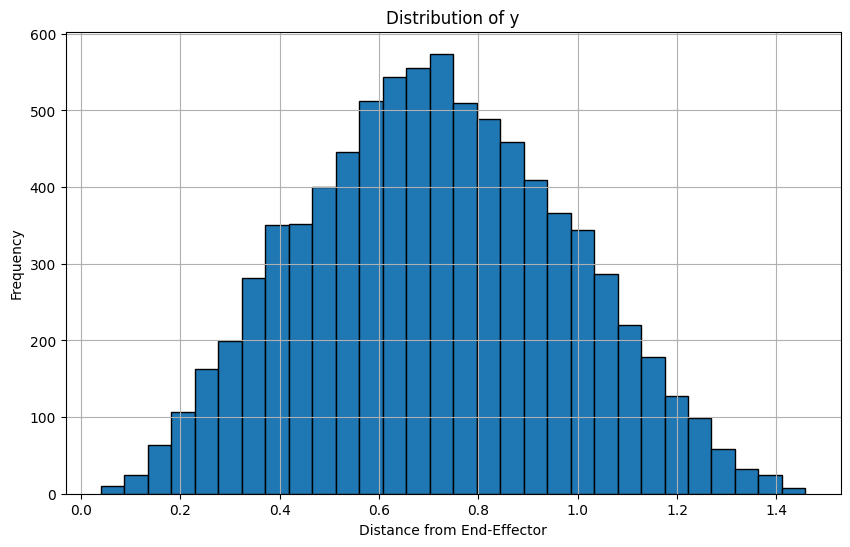

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['y'], bins=30, edgecolor='black')
plt.title('Distribution of y')
plt.xlabel('Distance from End-Effector')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)
print(f"Features: {X.shape}, Target: {y.shape}")

Features: (8192, 8), Target: (8192, 1)


In [ ]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X) #Standardizzazione
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

#To make use of numpyro, we need to transform the train data into jax arrays
X_train_jax = jnp.array(X_train)
y_train_jax = jnp.array(y_train).flatten()

#Bayesian Network

Using a 16 -> 8 neurons structure as in the previous notebook would result in the MCMC training going at a speed of about 1 it/s. This may suggest that, for the amount of data in this new dataset (about 8 times as before), a smaller and more nimble network could be a better choice. Therefore, we opted for 8 Neurons for each hidden layer. This increased the optimization rate to about 1.6 it/s, not enough. We finally accepted the use of a much smaller network with just 1 layer with 8 neurons. This choice allows for a 2-5 it/s speed which we found to be acceptable.

In [ ]:
def model(X, y=None):
    prior_std = 1.0 #We initialize the priors STD to 1

    n_features = X.shape[1]
    n_hidden = 8

    #Hidden layers
    w1 = numpyro.sample("w1", dist.Normal(jnp.zeros((n_features, n_hidden)), prior_std))
    b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(n_hidden), prior_std))
    z1 = jax.nn.relu(jnp.dot(X, w1) + b1)

    #Output
    w2 = numpyro.sample("w2", dist.Normal(jnp.zeros((n_hidden, 1)), prior_std))
    b2 = numpyro.sample("b2", dist.Normal(jnp.zeros(1), prior_std))
    mu = jnp.dot(z1, w2) + b2

    #Learnable parameter sigma for the variance. Halfnorma so sigma>0
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))

    #Likelihood
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Normal(mu.flatten(), sigma), obs=y)

#Markov Chain Monte Carlo BNN

Training Time: 22 Minutes

In [ ]:
#Key for reproducibility
rng_key = random.PRNGKey(0)
rng_key, rng_key_predict = random.split(rng_key)

nuts_kernel = NUTS(model) #Passing the defined model to NUTS

#MCMC through NUTS
mcmc = MCMC(
    nuts_kernel,
    num_samples=1000,    #Good samples
    num_warmup=1000,      #Burn-in samples
    num_chains=2        #Number of chains
)

mcmc.run(rng_key, X_train_jax, y_train_jax)

/tmp/ipykernel_437/4282559508.py:8: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 2000/2000 [11:21<00:00,  2.93it/s, 1023 steps of size 2.51e-03. acc. prob=0.94]


In [ ]:
predictive = Predictive(model, posterior_samples=mcmc.get_samples())

rng_key, rng_key_predict = random.split(rng_key)
predictions = predictive(rng_key_predict, X=jnp.array(X_test))

y_pred_samples = predictions['obs']

In [ ]:
y_pred_mean = jnp.mean(y_pred_samples, axis=0) #Mean
y_pred_std = jnp.std(y_pred_samples, axis=0) #STD

#95% Confidence intervals
lower_b = jnp.percentile(y_pred_samples, 2.5, axis=0)
upper_b = jnp.percentile(y_pred_samples, 97.5, axis=0)

#Inverting the scale back to the original
y_pred_mean_mpa = scaler_y.inverse_transform(y_pred_mean.reshape(-1, 1))
y_test_mpa = scaler_y.inverse_transform(y_test.reshape(-1, 1))

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_mpa, y_pred_mean_mpa))
print(f"RMSE: {rmse:.2f} m")
average_pred_std_mpa = np.mean(y_pred_std)*scaler_y.scale_
print(f"Average Predictive Std Dev: {average_pred_std_mpa.item():.2f} m")

RMSE: 0.11 m
Average Predictive Std Dev: 0.11 m


In [ ]:
is_inside = (y_test.flatten() >= lower_b) & (y_test.flatten() <= upper_b)
coverage = np.mean(is_inside) * 100

print(f"Coverage Probability (95% CI): {coverage:.2f}%")
print(f"Test set size: {len(y_test)}")
print(f"Correct predictions: {np.sum(is_inside)}")

Coverage Probability (95% CI): 96.46%
Test set size: 1639
Correct predictions: 1581


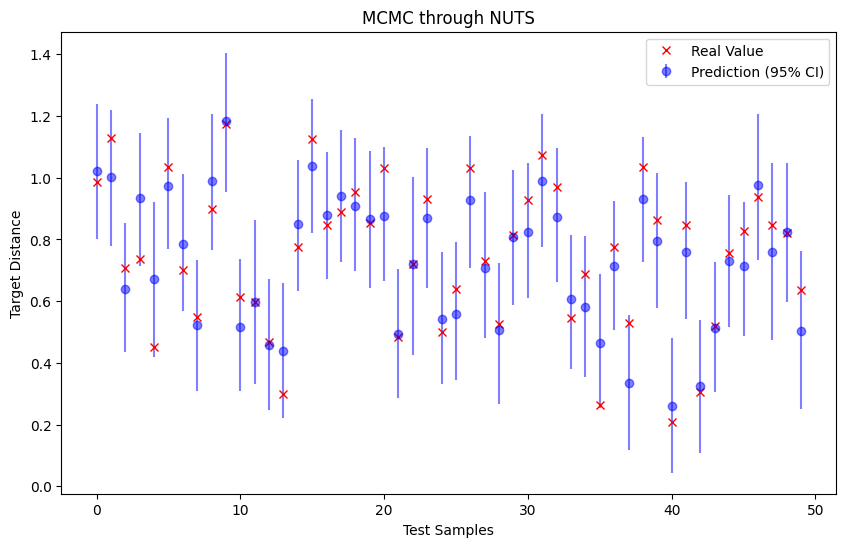

In [ ]:
plt.figure(figsize=(10, 6))

lower_error_distance = (y_pred_mean[:50] - lower_b[:50]) * scaler_y.scale_
upper_error_distance = (upper_b[:50] - y_pred_mean[:50]) * scaler_y.scale_

yerr_asymmetric = [lower_error_distance, upper_error_distance]

plt.errorbar(range(50), y_pred_mean_mpa[:50].flatten(), #50 samples
             yerr=yerr_asymmetric,
             fmt='o', color='blue', alpha=0.5, label='Prediction (95% CI)')
plt.plot(range(50), y_test_mpa[:50].flatten(), 'rx', label='Real Value')
plt.xlabel("Test Samples")
plt.ylabel("Target Distance")
plt.legend()
plt.title("MCMC through NUTS")
plt.show()

array([[<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'w2'}>, <Axes: title={'center': 'w2'}>]],
      dtype=object)

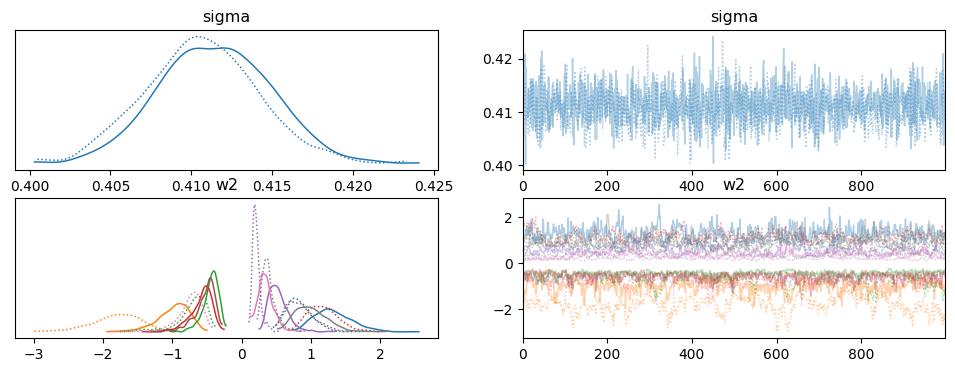

In [ ]:
idata = az.from_numpyro(mcmc)

#Trace Plot
az.plot_trace(idata, var_names=["sigma", "w2"])

From the trace plot above, we can see that the parameters estimation is quite stable, but not perfect. However, the R-Hat and Effective Sample Sizes are again quite bad. As with the other model, this is sometimes acceptable and we can focus on the model predictive capabilities.

In [ ]:
summary_df = az.summary(idata)

#Defining r-hat and ess thresholds
rhat_threshold = 1.05
ess_threshold = 100

bad_rhat = summary_df[summary_df['r_hat'] > rhat_threshold]
bad_ess_bulk = summary_df[summary_df['ess_bulk'] < ess_threshold]
bad_ess_tail = summary_df[summary_df['ess_tail'] < ess_threshold]

print(f"Number of parameters: {len(summary_df)}")
print(f"Parameters with a bad R-hat (> {rhat_threshold}): {len(bad_rhat)}")

"""ESS = Effective Sample Size. Bulk focuses on the bulk (95%) of the distr.
Tail focuses on the tails (5%) of the distributions. If the bulk ESS is a good
value, usually we can say that the point estimate is likely close to the real,
while if the tail ESS is a good value, we can usually say that the variance of
that parameter is likely well estimated."""

print(f"Parameters with a bad ESS Bulk (< {ess_threshold}): {len(bad_ess_bulk)}")
print(f"Parameters with a bad ESS Tail (< {ess_threshold}): {len(bad_ess_tail)}")

Number of parameters: 82
Parameters with a bad R-hat (> 1.05): 80
Parameters with a bad ESS Bulk (< 100): 80
Parameters with a bad ESS Tail (< 100): 58


#Stochastic Variational Inference

In [ ]:
#The guide is the approximating distribution q. AutoNormal assumes the parameters
#can be modeled as independent normal distributions, each with its own mean and variance
guide = autoguide.AutoNormal(model)
optimizer = Adam(step_size=0.01)

#Trace_ELBO is the negative of the ELBO, which we use as the loss function
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

Training Time: 8 minutes.

In [ ]:
svi_state = svi.init(random.PRNGKey(1), X_train_jax, y_train_jax)

elbo_history = []
num_steps = 2000

for i in range(num_steps):
    svi_state, loss = svi.update(svi_state, X_train_jax, y_train_jax)
    elbo_history.append(loss)

    if i % 100 == 0:
        print(f"Step {i} - Loss (Negative ELBO): {loss:.4f}")

params = svi.get_params(svi_state)

Step 0 - Loss (Negative ELBO): 42200.6562
Step 100 - Loss (Negative ELBO): 14425.9727
Step 200 - Loss (Negative ELBO): 12522.1123
Step 300 - Loss (Negative ELBO): 10447.8730
Step 400 - Loss (Negative ELBO): 8144.3525
Step 500 - Loss (Negative ELBO): 7073.8369
Step 600 - Loss (Negative ELBO): 6153.7168
Step 700 - Loss (Negative ELBO): 5899.9233
Step 800 - Loss (Negative ELBO): 5760.2031
Step 900 - Loss (Negative ELBO): 5609.8364
Step 1000 - Loss (Negative ELBO): 5626.7285
Step 1100 - Loss (Negative ELBO): 5912.5249
Step 1200 - Loss (Negative ELBO): 5460.5464
Step 1300 - Loss (Negative ELBO): 5410.5293
Step 1400 - Loss (Negative ELBO): 5334.6006
Step 1500 - Loss (Negative ELBO): 5340.2915
Step 1600 - Loss (Negative ELBO): 5265.9707
Step 1700 - Loss (Negative ELBO): 5204.0493
Step 1800 - Loss (Negative ELBO): 5130.7246
Step 1900 - Loss (Negative ELBO): 5141.6533


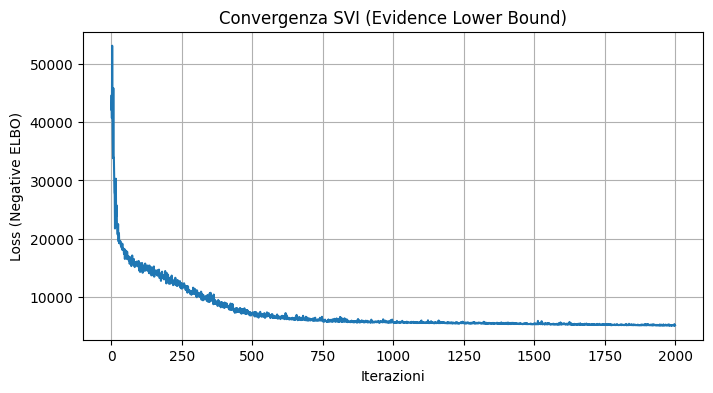

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(elbo_history)
plt.title("Convergenza SVI (Evidence Lower Bound)")
plt.xlabel("Iterazioni")
plt.ylabel("Loss (Negative ELBO)")
plt.grid(True)
plt.show()

In [ ]:
#Dopo aver ottenuto la nostra approssimazione, possiamo usarla per ottenere,
#similmente a prima, 1000 stime per ogni input del test set
predictive_svi = Predictive(model, guide=guide, params=params, num_samples=1000)
svi_samples = predictive_svi(random.PRNGKey(2), X=jnp.array(X_test)) #(1000, 206)

In [ ]:
y_pred_mean_VI = jnp.mean(svi_samples['obs'], axis=0) #(206,)
y_pred_std_VI = jnp.std(svi_samples['obs'], axis=0) # La STD delle 1000 previsioni per ciascun campione di test

#95% Confidence intervals, calcolati sui campioni raw per ogni osservazione
lower_b_VI = jnp.percentile(svi_samples['obs'], 2.5, axis=0)
upper_b_VI = jnp.percentile(svi_samples['obs'], 97.5, axis=0)

#Inverting the scale back to the original
y_pred_mean_mpa_VI = scaler_y.inverse_transform(y_pred_mean_VI.reshape(-1, 1))
y_test_mpa = scaler_y.inverse_transform(y_test.reshape(-1, 1))

In [ ]:
rmse_VI = np.sqrt(mean_squared_error(y_test_mpa, y_pred_mean_mpa_VI))
print(f"RMSE: {rmse_VI:.2f} m")

average_pred_std_VI_mpa = np.mean(y_pred_std_VI) * scaler_y.scale_
print(f"Average Predictive Std Dev: {average_pred_std_VI_mpa.item():.2f} m")

RMSE: 0.13 m
Average Predictive Std Dev: 0.13 m


In [ ]:
is_inside_VI = (y_test.flatten() >= lower_b_VI) & (y_test.flatten() <= upper_b_VI)
coverage_VI = np.mean(is_inside_VI)*100

print(f"Coverage Probability (95% CI): {coverage_VI:.2f}%")
print(f"Test set size: {len(y_test)}")
print(f"Correct predictions: {np.sum(is_inside_VI)}")

Coverage Probability (95% CI): 94.39%
Test set size: 1639
Correct predictions: 1547


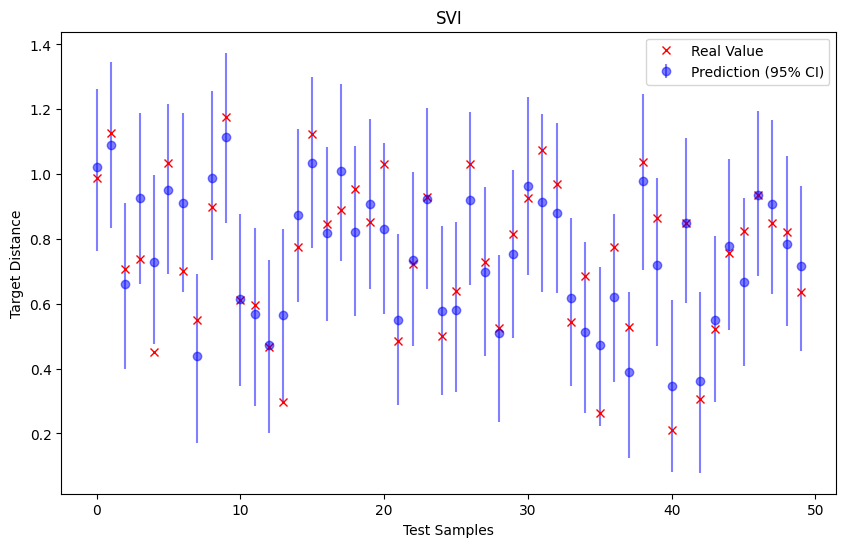

In [ ]:
plt.figure(figsize=(10, 6))

lower_error_distance_VI = (y_pred_mean_VI[:50] - lower_b_VI[:50])*scaler_y.scale_
upper_error_distance_VI = (upper_b_VI[:50] - y_pred_mean_VI[:50])*scaler_y.scale_

yerr_asymmetric_VI = [lower_error_distance_VI, upper_error_distance_VI]

plt.errorbar(range(50), y_pred_mean_mpa_VI[:50].flatten(), #50 samples
             yerr=yerr_asymmetric_VI,
             fmt='o', color='blue', alpha=0.5, label='Prediction (95% CI)')
plt.plot(range(50), y_test_mpa[:50].flatten(), 'rx', label='Real Value')
plt.xlabel("Test Samples")
plt.ylabel("Target Distance")
plt.legend()
plt.title("SVI")
plt.show()

#Performances and Comparison with Concrete Dataset

The kin8nm Dataset contains 8192 joint angles observations together with the correspondant distance between the end-effector and a certain target. This is a bigger Dataset then the concrete one.

Because of the size of the dataset, a smaller network of just 1 hidden layer with 8 neurons was used. With 1000 warmup samples and 1000 saved samples, the MCMC approach needed 22 minutes to converge using 2 chains. This contrasts with the much faster 8 minutes of training for the SVI, using 2000 optmizations steps. As predicted in the other notebook, on bigger datasets the increase in efficieny of SVI compared to MCMC becomes more and more apparent.

Performances wide, on the concrete dataset, MCMC showed much better performances with a substantially lower RMSE and useful confidence intervals, against the large RMSE and very large, and therefore useless, confidence intervals of SVI. The situation on the kin8nm dataset is very different, both models behave very well with an RMSE of 0.11m (MCMC) and 0.13m (SVI). The values are also very close to the average variance over the predicted samples, suggesting the models are modeling well the inherent data noise. The coverage probability are about 96% and 94% respectively.

While on the concrete dataset the slightly slower MCMC showed much better predictive power, on the kin8nm the much faster SVI shows very similar performances with less then half the training time. In this case, SVI would be the more sensible choice, showing the capabilities of the SVI method when used on large enough datasets.